In [1]:
import sqlite3
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path.cwd().parent

DATABASE_PATH = BASE_DIR / "database" / "cybersight.db"

conn = sqlite3.connect(DATABASE_PATH)

print("Connected Successfully!")

Connected Successfully!


In [3]:
def run_query(query):
    """
    Execute SQL query and return a DataFrame.
    """
    return pd.read_sql_query(query, conn)

In [4]:
query = """
SELECT COUNT(*) AS total_records
FROM network_logs;
"""

run_query(query)

,total_records
0,257673


In [5]:
query = """
PRAGMA table_info(network_logs);
"""

columns = run_query(query)

print(f"Total Columns : {len(columns)}")

columns.head()

Total Columns : 52


,cid,name,type,notnull,dflt_value,pk
0,0,record_id,INTEGER,0,None,1
1,1,id,INTEGER,0,None,0
2,2,dur,REAL,0,None,0
3,3,proto,TEXT,0,None,0
4,4,service,TEXT,0,None,0


In [6]:
query = """
SELECT *
FROM network_logs
LIMIT 5;
"""

run_query(query)

,record_id,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,...,ct_srv_dst,is_sm_ips_ports,attack_cat,label,dataset,total_bytes,total_packets,bytes_per_packet,traffic_direction_ratio,packet_direction_ratio
0,1,1,0.000011,udp,-,INT,2,0,496,0,...,2,0,Normal,0,train,496.0,2.0,165.333333,496.0,2.0
1,2,2,0.000008,udp,-,INT,2,0,1762,0,...,2,0,Normal,0,train,1762.0,2.0,587.333333,1762.0,2.0
2,3,3,0.000005,udp,-,INT,2,0,1068,0,...,3,0,Normal,0,train,1068.0,2.0,356.000000,1068.0,2.0
3,4,4,0.000006,udp,-,INT,2,0,900,0,...,3,0,Normal,0,train,900.0,2.0,300.000000,900.0,2.0
4,5,5,0.000010,udp,-,INT,2,0,2126,0,...,3,0,Normal,0,train,2126.0,2.0,708.666667,2126.0,2.0


# Basic Network Traffic Analysis

In [7]:
query = """
SELECT
    label,
    COUNT(*) AS total_records
FROM network_logs
GROUP BY label;
"""

run_query(query)

,label,total_records
0,0,93000
1,1,164673


In [8]:
query = """
SELECT
    CASE
        WHEN label = 0 THEN 'Normal'
        ELSE 'Attack'
    END AS traffic_type,

    COUNT(*) AS total_records

FROM network_logs

GROUP BY label;
"""

run_query(query)

,traffic_type,total_records
0,Normal,93000
1,Attack,164673


In [9]:
query = """
SELECT

    CASE
        WHEN label = 0 THEN 'Normal'
        ELSE 'Attack'
    END AS traffic_type,

    COUNT(*) AS total_records,

    ROUND(
        COUNT(*) * 100.0 /
        (SELECT COUNT(*) FROM network_logs),
        2
    ) AS percentage

FROM network_logs

GROUP BY label;
"""

run_query(query)

,traffic_type,total_records,percentage
0,Normal,93000,36.09
1,Attack,164673,63.91


In [10]:
query = """
SELECT
    attack_cat,
    COUNT(*) AS total_records

FROM network_logs

GROUP BY attack_cat

ORDER BY total_records DESC;
"""

run_query(query)

,attack_cat,total_records
0,Normal,93000
1,Generic,58871
2,Exploits,44525
3,Fuzzers,24246
4,DoS,16353
5,Reconnaissance,13987
6,Analysis,2677
7,Backdoor,2329
8,Shellcode,1511
9,Worms,174


In [11]:
query = """
SELECT
    proto,
    COUNT(*) AS total_records

FROM network_logs

GROUP BY proto

ORDER BY total_records DESC

LIMIT 10;
"""

run_query(query)

,proto,total_records
0,tcp,123041
1,udp,92701
2,unas,15599
3,arp,3846
4,ospf,3271
5,sctp,1474
6,any,396
7,gre,313
8,rsvp,264
9,ipv6,262


In [12]:
query = """
SELECT
    service,
    COUNT(*) AS total_records

FROM network_logs

GROUP BY service

ORDER BY total_records DESC

LIMIT 10;
"""

run_query(query)

,service,total_records
0,-,141321
1,dns,68661
2,http,27011
3,smtp,6909
4,ftp-data,5391
5,ftp,4980
6,pop3,1528
7,ssh,1506
8,dhcp,120
9,snmp,109


In [13]:
query = """
SELECT
    state,
    COUNT(*) AS total_records

FROM network_logs

GROUP BY state

ORDER BY total_records DESC;
"""

run_query(query)

,state,total_records
0,FIN,117164
1,INT,116438
2,CON,20134
3,REQ,3833
4,RST,84
5,ECO,12
6,ACC,4
7,no,1
8,URN,1
9,PAR,1


# Attack Analysis

In [14]:
query = """
SELECT
    attack_cat,
    ROUND(SUM(total_bytes),2) AS total_bytes_transferred

FROM network_logs

GROUP BY attack_cat

ORDER BY total_bytes_transferred DESC;
"""

run_query(query)

,attack_cat,total_bytes_transferred
0,Normal,2.811450e+09
1,Exploits,2.110621e+09
2,DoS,6.558849e+08
3,Fuzzers,1.765854e+08
4,Generic,1.039664e+08
5,Reconnaissance,3.564546e+07
6,Worms,1.378450e+07
7,Backdoor,4.229827e+06
8,Analysis,3.040616e+06
9,Shellcode,1.026324e+06


In [15]:
query = """
SELECT
    attack_cat,
    ROUND(AVG(dur),6) AS avg_duration

FROM network_logs

GROUP BY attack_cat

ORDER BY avg_duration DESC;
"""

run_query(query)

,attack_cat,avg_duration
0,Fuzzers,2.673938
1,DoS,2.448795
2,Backdoor,2.224558
3,Exploits,2.122902
4,Analysis,1.416942
5,Worms,1.333305
6,Normal,1.015407
7,Reconnaissance,1.005046
8,Shellcode,0.362856
9,Generic,0.061157


In [16]:
query = """
SELECT
    attack_cat,
    ROUND(AVG(total_packets),2) AS avg_packets

FROM network_logs

GROUP BY attack_cat

ORDER BY avg_packets DESC;
"""

run_query(query)

,attack_cat,avg_packets
0,Worms,81.15
1,Normal,60.59
2,Exploits,57.34
3,DoS,45.37
4,Fuzzers,19.86
5,Reconnaissance,12.02
6,Shellcode,9.25
7,Backdoor,8.23
8,Analysis,7.48
9,Generic,3.74


In [17]:
query = """
SELECT
    attack_cat,
    ROUND(AVG(bytes_per_packet),2) AS avg_bytes_per_packet

FROM network_logs

GROUP BY attack_cat

ORDER BY avg_bytes_per_packet DESC;
"""

run_query(query)

,attack_cat,avg_bytes_per_packet
0,Worms,301.82
1,Exploits,233.97
2,Normal,198.37
3,Fuzzers,176.98
4,DoS,123.13
5,Shellcode,86.60
6,Backdoor,79.44
7,Analysis,78.59
8,Reconnaissance,59.95
9,Generic,45.98


In [18]:
query = """
SELECT
    attack_cat,
    ROUND(AVG(traffic_direction_ratio),2) AS avg_direction_ratio

FROM network_logs

GROUP BY attack_cat

ORDER BY avg_direction_ratio DESC;
"""

run_query(query)

,attack_cat,avg_direction_ratio
0,Backdoor,740.21
1,DoS,621.20
2,Fuzzers,428.20
3,Exploits,366.98
4,Analysis,357.28
5,Reconnaissance,218.76
6,Shellcode,174.84
7,Generic,123.71
8,Worms,123.59
9,Normal,54.21


In [19]:
query = """
SELECT
    attack_cat,
    ROUND(AVG(packet_direction_ratio),2) AS avg_packet_ratio

FROM network_logs

GROUP BY attack_cat

ORDER BY avg_packet_ratio DESC;
"""

run_query(query)

,attack_cat,avg_packet_ratio
0,Backdoor,4.75
1,DoS,4.34
2,Fuzzers,3.22
3,Exploits,2.95
4,Analysis,2.88
5,Reconnaissance,2.27
6,Generic,2.02
7,Shellcode,1.67
8,Worms,1.28
9,Normal,1.20


In [20]:
query = """
SELECT

    attack_cat,
    proto,
    service,
    total_bytes,
    total_packets

FROM network_logs

ORDER BY total_bytes DESC

LIMIT 20;
"""

run_query(query)

,attack_cat,proto,service,total_bytes,total_packets
0,DoS,tcp,pop3,14728231.0,12660.0
1,DoS,tcp,pop3,14726784.0,12628.0
2,DoS,tcp,pop3,14725673.0,12602.0
3,DoS,tcp,pop3,14661547.0,12514.0
4,DoS,tcp,pop3,14562299.0,12488.0
5,Exploits,tcp,smtp,14423800.0,12228.0
6,Exploits,tcp,-,13742667.0,11718.0
7,Exploits,tcp,smtp,13027669.0,11068.0
8,DoS,tcp,pop3,12901337.0,11118.0
9,Exploits,tcp,smtp,12655197.0,10906.0


In [21]:
query = """
SELECT

    attack_cat,

    MAX(bytes_per_packet) AS largest_packet

FROM network_logs

GROUP BY attack_cat

ORDER BY largest_packet DESC;
"""

run_query(query)

,attack_cat,largest_packet
0,Normal,1284.857143
1,Generic,1202.759283
2,Exploits,1194.151063
3,DoS,1191.818339
4,Fuzzers,1177.129539
5,Reconnaissance,1176.535074
6,Worms,1168.208386
7,Backdoor,909.869091
8,Analysis,909.869091
9,Shellcode,491.333333


# Comparative Attack Analysis

In [22]:
query = """
SELECT
    attack_cat,
    proto,
    COUNT(*) AS total_connections

FROM network_logs

WHERE label = 1

GROUP BY attack_cat, proto

ORDER BY attack_cat, total_connections DESC;
"""

run_query(query)

,attack_cat,proto,total_connections
0,Analysis,unas,926
1,Analysis,tcp,622
2,Analysis,ospf,75
3,Analysis,sctp,26
4,Analysis,any,24
...,...,...,...
895,Reconnaissance,3pc,7
896,Shellcode,udp,761
897,Shellcode,tcp,750
898,Worms,tcp,153


In [23]:
query = """
SELECT
    service,
    COUNT(*) AS attack_count

FROM network_logs

WHERE label = 1

GROUP BY service

ORDER BY attack_count DESC

LIMIT 10;
"""

run_query(query)

,service,attack_count
0,-,77434
1,dns,58100
2,http,17650
3,smtp,4695
4,ftp,3004
5,ftp-data,1890
6,pop3,1524
7,dhcp,120
8,snmp,108
9,ssl,86


In [24]:
query = """
SELECT

    proto,

    COUNT(*) AS total_connections,

    SUM(label) AS attack_connections,

    ROUND(
        SUM(label) * 100.0 /
        COUNT(*),
        2
    ) AS attack_percentage

FROM network_logs

GROUP BY proto

HAVING COUNT(*) >= 1000

ORDER BY attack_percentage DESC;
"""

protocol_attack = run_query(query)

protocol_attack

,proto,total_connections,attack_connections,attack_percentage
0,unas,15599,15599,100.00
1,sctp,1474,1474,100.00
2,ospf,3271,3169,96.88
3,udp,92701,70682,76.25
4,tcp,123041,56072,45.57
5,arp,3846,0,0.00


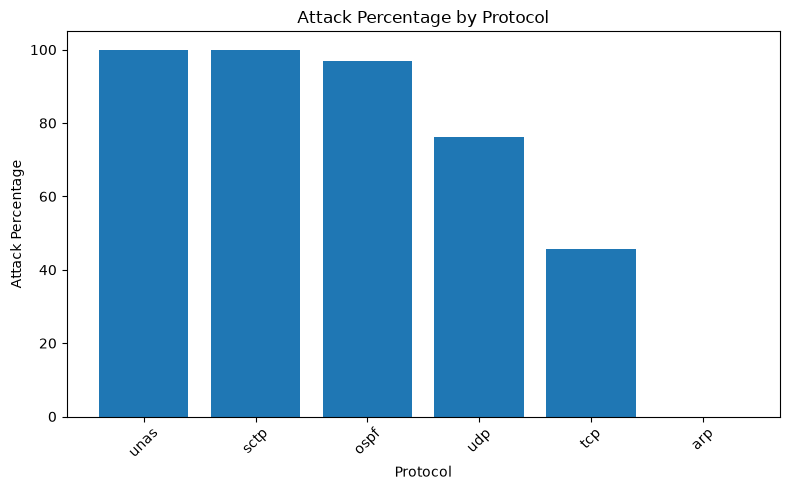

<Figure size 640x480 with 0 Axes>

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    protocol_attack["proto"],
    protocol_attack["attack_percentage"]
)

plt.title("Attack Percentage by Protocol")
plt.xlabel("Protocol")
plt.ylabel("Attack Percentage")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()
plt.savefig("../images/attackpercentagesql.png", dpi=300, bbox_inches="tight")

In [26]:
query = """
SELECT

    service,

    COUNT(*) AS total_connections,

    SUM(label) AS attack_connections,

    ROUND(
        SUM(label) * 100.0 /
        COUNT(*),
        2
    ) AS attack_percentage

FROM network_logs

GROUP BY service

HAVING COUNT(*) >= 100

ORDER BY attack_percentage DESC;
"""

service_attack = run_query(query)

service_attack

,service,total_connections,attack_connections,attack_percentage
0,dhcp,120,120,100.00
1,pop3,1528,1524,99.74
2,snmp,109,108,99.08
3,dns,68661,58100,84.62
4,smtp,6909,4695,67.95
5,http,27011,17650,65.34
6,ftp,4980,3004,60.32
7,-,141321,77434,54.79
8,ftp-data,5391,1890,35.06
9,ssh,1506,15,1.00


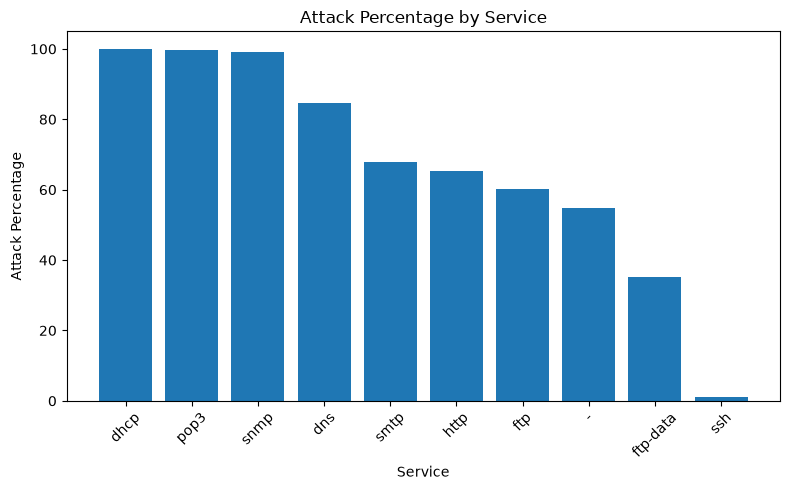

<Figure size 640x480 with 0 Axes>

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    service_attack["service"],
    service_attack["attack_percentage"]
)

plt.title("Attack Percentage by Service")
plt.xlabel("Service")
plt.ylabel("Attack Percentage")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()
plt.savefig("../images/attackpercentage2sql.png", dpi=300, bbox_inches="tight")

In [28]:
query = """
SELECT

    state,

    COUNT(*) AS total_connections,

    SUM(label) AS attack_connections,

    ROUND(
        SUM(label) * 100.0 /
        COUNT(*),
        2
    ) AS attack_percentage

FROM network_logs

GROUP BY state

ORDER BY attack_percentage DESC;
"""

run_query(query)

,state,total_connections,attack_connections,attack_percentage
0,CLO,1,1,100.00
1,INT,116438,106238,91.24
2,ACC,4,2,50.00
3,FIN,117164,55817,47.64
4,REQ,3833,1201,31.33
5,RST,84,12,14.29
6,CON,20134,1402,6.96
7,no,1,0,0.00
8,URN,1,0,0.00
9,PAR,1,0,0.00


In [29]:
query = """
SELECT

    proto,

    ROUND(SUM(total_bytes),2) AS total_bytes

FROM network_logs

GROUP BY proto

ORDER BY total_bytes DESC;
"""

run_query(query)

,proto,total_bytes
0,tcp,5.814159e+09
1,sctp,3.529227e+07
2,udp,3.401985e+07
3,ospf,2.585095e+07
4,unas,3.119800e+06
...,...,...
128,egp,2.358000e+04
129,argus,2.358000e+04
130,igmp,1.887800e+04
131,rtp,8.994000e+03


In [30]:
query = """
SELECT

    service,

    ROUND(SUM(total_bytes),2) AS total_bytes

FROM network_logs

GROUP BY service

ORDER BY total_bytes DESC

LIMIT 10;
"""

run_query(query)

,service,total_bytes
0,-,2.747442e+09
1,http,1.392985e+09
2,smtp,1.364306e+09
3,pop3,2.890911e+08
4,ftp-data,4.686123e+07
5,ssh,3.171501e+07
6,ftp,2.335785e+07
7,dns,1.451987e+07
8,ssl,5.581058e+06
9,dhcp,2.595260e+05


# Threat Hunting & Security Investigation

In [31]:
query = """
SELECT

    record_id,
    attack_cat,
    proto,
    service,
    state,

    total_bytes,
    total_packets,
    bytes_per_packet

FROM network_logs

ORDER BY total_bytes DESC

LIMIT 20;
"""

largest_connections = run_query(query)

largest_connections

,record_id,attack_cat,proto,service,state,total_bytes,total_packets,bytes_per_packet
0,516,DoS,tcp,pop3,FIN,14728231.0,12660.0,1163.275492
1,154821,DoS,tcp,pop3,FIN,14726784.0,12628.0,1166.108480
2,44144,DoS,tcp,pop3,FIN,14725673.0,12602.0,1168.426010
3,10555,DoS,tcp,pop3,CON,14661547.0,12514.0,1171.517938
4,165271,DoS,tcp,pop3,CON,14562299.0,12488.0,1166.010009
5,9537,Exploits,tcp,smtp,CON,14423800.0,12228.0,1179.475018
6,61813,Exploits,tcp,-,CON,13742667.0,11718.0,1172.682567
7,179521,Exploits,tcp,smtp,CON,13027669.0,11068.0,1176.950854
8,203433,DoS,tcp,pop3,CON,12901337.0,11118.0,1160.296519
9,144375,Exploits,tcp,smtp,CON,12655197.0,10906.0,1160.282112


In [32]:
query = """
SELECT

    record_id,
    attack_cat,
    proto,
    service,
    dur,
    total_bytes

FROM network_logs

ORDER BY dur DESC

LIMIT 20;
"""

longest_sessions = run_query(query)

longest_sessions

,record_id,attack_cat,proto,service,dur,total_bytes
0,70536,Normal,arp,-,59.999989,92.0
1,70537,Normal,arp,-,59.999989,92.0
2,191434,Normal,arp,-,59.999989,92.0
3,191507,Normal,arp,-,59.999989,92.0
4,191510,Normal,arp,-,59.999989,92.0
5,191511,Normal,arp,-,59.999989,92.0
6,189939,Normal,arp,-,59.999985,92.0
7,189940,Normal,arp,-,59.999985,92.0
8,124921,Normal,arp,-,59.999966,92.0
9,124922,Normal,arp,-,59.999966,92.0


In [33]:
query = """
SELECT

    record_id,
    attack_cat,
    proto,
    service,

    total_packets,
    total_bytes

FROM network_logs

ORDER BY total_packets DESC

LIMIT 20;
"""

highest_packets = run_query(query)

highest_packets

,record_id,attack_cat,proto,service,total_packets,total_bytes
0,516,DoS,tcp,pop3,12660.0,14728231.0
1,154821,DoS,tcp,pop3,12628.0,14726784.0
2,44144,DoS,tcp,pop3,12602.0,14725673.0
3,10555,DoS,tcp,pop3,12514.0,14661547.0
4,165271,DoS,tcp,pop3,12488.0,14562299.0
5,9537,Exploits,tcp,smtp,12228.0,14423800.0
6,61813,Exploits,tcp,-,11718.0,13742667.0
7,203433,DoS,tcp,pop3,11118.0,12901337.0
8,179521,Exploits,tcp,smtp,11068.0,13027669.0
9,144375,Exploits,tcp,smtp,10906.0,12655197.0


In [34]:
query = """
SELECT

    record_id,
    attack_cat,
    proto,
    service,

    bytes_per_packet

FROM network_logs

ORDER BY bytes_per_packet DESC

LIMIT 20;
"""

largest_packets = run_query(query)

largest_packets

,record_id,attack_cat,proto,service,bytes_per_packet
0,105584,Normal,rtp,-,1284.857143
1,213225,Generic,tcp,http,1202.759283
2,53456,Generic,tcp,http,1202.520795
3,242831,Generic,tcp,http,1200.601763
4,53313,Generic,tcp,http,1199.148130
5,52741,Generic,tcp,http,1197.803655
6,228488,Generic,tcp,http,1195.363973
7,202889,Exploits,tcp,http,1194.151063
8,45179,Generic,tcp,http,1192.306273
9,11209,DoS,tcp,http,1191.818339


In [35]:
query = """
SELECT

    record_id,
    attack_cat,
    proto,
    service,

    traffic_direction_ratio

FROM network_logs

ORDER BY traffic_direction_ratio DESC

LIMIT 20;
"""

direction_ratio = run_query(query)

direction_ratio

,record_id,attack_cat,proto,service,traffic_direction_ratio
0,144805,Fuzzers,ospf,-,54944.0
1,144807,Reconnaissance,ospf,-,54944.0
2,144809,DoS,ospf,-,54944.0
3,144810,DoS,ospf,-,54944.0
4,144811,Exploits,ospf,-,54944.0
5,145133,Exploits,ospf,-,54944.0
6,145136,Exploits,ospf,-,54944.0
7,145138,Exploits,ospf,-,54944.0
8,145544,DoS,ospf,-,54944.0
9,146064,DoS,ospf,-,54944.0


In [36]:
query = """
SELECT

    record_id,
    attack_cat,
    proto,
    service,

    packet_direction_ratio

FROM network_logs

ORDER BY packet_direction_ratio DESC

LIMIT 20;
"""

packet_ratio = run_query(query)

packet_ratio

,record_id,attack_cat,proto,service,packet_direction_ratio
0,136834,Fuzzers,udp,dns,512.0
1,174617,DoS,udp,-,398.0
2,142131,DoS,udp,-,370.0
3,212076,DoS,udp,-,362.0
4,167639,Fuzzers,udp,dns,344.0
5,3730,DoS,udp,-,322.0
6,49626,DoS,udp,-,292.0
7,201101,Fuzzers,udp,dns,264.0
8,218104,Fuzzers,udp,dns,264.0
9,131087,Fuzzers,udp,dns,254.0


In [37]:
query = """
SELECT

    attack_cat,
    proto,
    service,

    total_bytes,
    total_packets

FROM network_logs

WHERE label = 1

ORDER BY total_bytes DESC

LIMIT 20;
"""

high_volume_attacks = run_query(query)

high_volume_attacks

,attack_cat,proto,service,total_bytes,total_packets
0,DoS,tcp,pop3,14728231.0,12660.0
1,DoS,tcp,pop3,14726784.0,12628.0
2,DoS,tcp,pop3,14725673.0,12602.0
3,DoS,tcp,pop3,14661547.0,12514.0
4,DoS,tcp,pop3,14562299.0,12488.0
5,Exploits,tcp,smtp,14423800.0,12228.0
6,Exploits,tcp,-,13742667.0,11718.0
7,Exploits,tcp,smtp,13027669.0,11068.0
8,DoS,tcp,pop3,12901337.0,11118.0
9,Exploits,tcp,smtp,12655197.0,10906.0


In [38]:
query = """
SELECT

    record_id,
    attack_cat,
    proto,
    service,
    state,

    dur,
    total_bytes,
    total_packets,
    bytes_per_packet

FROM network_logs

WHERE label = 1

ORDER BY

    total_bytes DESC,

    total_packets DESC,

    dur DESC

LIMIT 10;
"""

run_query(query)

,record_id,attack_cat,proto,service,state,dur,total_bytes,total_packets,bytes_per_packet
0,516,DoS,tcp,pop3,FIN,57.237827,14728231.0,12660.0,1163.275492
1,154821,DoS,tcp,pop3,FIN,57.953392,14726784.0,12628.0,1166.108480
2,44144,DoS,tcp,pop3,FIN,54.265602,14725673.0,12602.0,1168.426010
3,10555,DoS,tcp,pop3,CON,59.983105,14661547.0,12514.0,1171.517938
4,165271,DoS,tcp,pop3,CON,59.962872,14562299.0,12488.0,1166.010009
5,9537,Exploits,tcp,smtp,CON,59.944077,14423800.0,12228.0,1179.475018
6,61813,Exploits,tcp,-,CON,59.932209,13742667.0,11718.0,1172.682567
7,179521,Exploits,tcp,smtp,CON,59.970360,13027669.0,11068.0,1176.950854
8,203433,DoS,tcp,pop3,CON,59.844826,12901337.0,11118.0,1160.296519
9,144375,Exploits,tcp,smtp,CON,59.983932,12655197.0,10906.0,1160.282112


# Key Findings

Based on the SQL analysis, the following observations were made regarding the UNSW-NB15 network traffic dataset.

In [39]:
findings = [
    "• 63.91% of the network traffic consists of malicious connections.",
    "• Generic and Exploit attacks account for the majority of malicious traffic.",
    "• TCP carries the highest overall network traffic volume.",
    "• UDP and OSPF exhibit considerably higher attack percentages than TCP.",
    "• POP3, DHCP and DNS services show very high malicious traffic proportions in this dataset.",
    "• Exploit and DoS attacks generate the largest network data transfers.",
    "• The engineered features (total_bytes, total_packets and bytes_per_packet) successfully highlighted high-volume attack sessions.",
    "• Several attack sessions exceeded 14 million bytes and 12,000 packets, making them strong candidates for further investigation.",
    "• Highly asymmetric traffic patterns were observed for multiple OSPF-based attack sessions.",
    "• Long-duration sessions are not necessarily malicious; several of the longest sessions belonged to normal ARP traffic."
]

for finding in findings:
    print(finding)

• 63.91% of the network traffic consists of malicious connections.
• Generic and Exploit attacks account for the majority of malicious traffic.
• TCP carries the highest overall network traffic volume.
• UDP and OSPF exhibit considerably higher attack percentages than TCP.
• POP3, DHCP and DNS services show very high malicious traffic proportions in this dataset.
• Exploit and DoS attacks generate the largest network data transfers.
• The engineered features (total_bytes, total_packets and bytes_per_packet) successfully highlighted high-volume attack sessions.
• Several attack sessions exceeded 14 million bytes and 12,000 packets, making them strong candidates for further investigation.
• Highly asymmetric traffic patterns were observed for multiple OSPF-based attack sessions.
• Long-duration sessions are not necessarily malicious; several of the longest sessions belonged to normal ARP traffic.


# Security Recommendations

The following recommendations are derived from the SQL analysis.

In [40]:
recommendations = [
    "Prioritize monitoring of Exploit and DoS attack categories.",
    "Deploy anomaly detection for unusually large network transfers.",
    "Implement protocol-specific monitoring for UDP and OSPF traffic.",
    "Continuously inspect POP3, DNS and SMTP services for abnormal behavior.",
    "Investigate highly asymmetric traffic patterns, as they may indicate scanning or data exfiltration.",
    "Use engineered traffic features as additional inputs for machine learning intrusion detection."
]

for recommendation in recommendations:
    print(f"• {recommendation}")

• Prioritize monitoring of Exploit and DoS attack categories.
• Deploy anomaly detection for unusually large network transfers.
• Implement protocol-specific monitoring for UDP and OSPF traffic.
• Continuously inspect POP3, DNS and SMTP services for abnormal behavior.
• Investigate highly asymmetric traffic patterns, as they may indicate scanning or data exfiltration.
• Use engineered traffic features as additional inputs for machine learning intrusion detection.
